# Task-01

Implement a linear regression model to predict the prices of houses based on their square footage and the number of bedrooms and bathrooms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
train = pd.read_csv("C://Users//srivi//Downloads//house-prices-advanced-regression-techniques (1)//train.csv")
test = pd.read_csv("C://Users//srivi//Downloads//house-prices-advanced-regression-techniques (1)//test.csv")

In [36]:
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
target = 'SalePrice'

X = train[features]
y = train[target]

In [20]:
print(X.isnull().sum().sum())

0


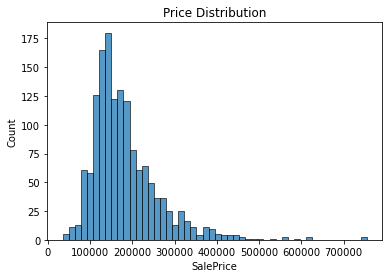

In [31]:
sns.histplot(train['SalePrice'], bins=50)
plt.title("Price Distribution")
plt.show()

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred = model.predict(X_test)

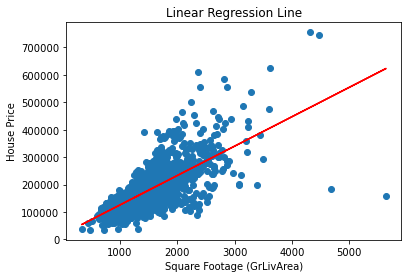

In [42]:
X_single = train[['GrLivArea']]
y_target = train['SalePrice']

model = LinearRegression()
model.fit(X_single, y_target)

y_predict = model.predict(X_single)

plt.scatter(X_single, y_target)
plt.plot(X_single, y_predict , c='r')

plt.xlabel("Square Footage (GrLivArea)")
plt.ylabel("House Price")
plt.title("Linear Regression Line")

plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 35788.061292436294
RMSE: 52975.71771338122
R2 Score: 0.6341189942328371


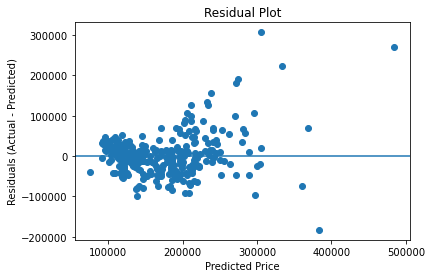

In [41]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

In [25]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 52261.748626944594
Coefficients: [   104.02630701 -26655.16535734  30014.32410896]


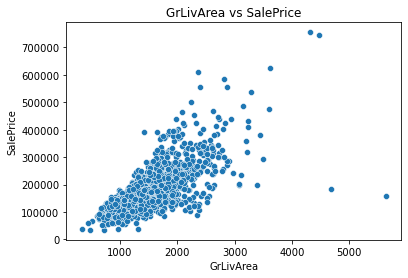

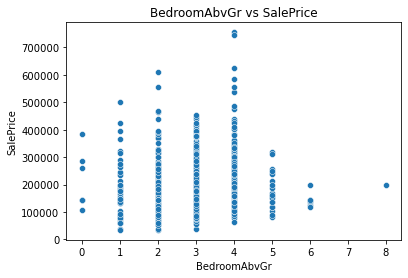

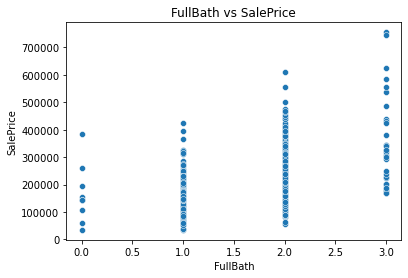

In [40]:
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']

for feature in features:
    sns.scatterplot(x=train[feature], y=train['SalePrice'])
    plt.title(f"{feature} vs SalePrice")
    plt.show()

In [26]:
X_test = test[features]
X_test = X_test.fillna(X_test.mean())

test_predictions = model.predict(X_test)

In [11]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_predictions
})

submission.to_csv("C://Users//srivi//Downloads//submission.csv", index=False)